In [ ]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images
using Statistics

In [38]:
function load_crop_imgs(filenames, pathdir, x_crop, y_crop)
    imgs_atoms, imgs_bkg, imgs_dark, amplitude_laser = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"])), x_crop, y_crop)
            img_bkg = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"])), x_crop, y_crop)
            img_dark = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"])), x_crop, y_crop)
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(amplitude_laser, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, amplitude_laser
end

function crop_img(img, x_crop, y_crop)
    return img[y_crop, x_crop]
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, Amplitude_laser, t_exp)
    ODs = zeros(size(imgs_atoms))
    for i in 1:size(imgs_atoms)[1]
        for j = 1:size(imgs_atoms)[2]
            OD = (imgs_atoms[i, j, :, :] .- imgs_dark[i, j, :, :]) ./ (imgs_bkg[i, j, :, :] .- imgs_dark[i, j, :, :])

            OD[OD .<= 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
            OD .= -log10.(OD)
            OD[isnan.(OD)] .= 0 # Map Nan values to 0
            OD[OD .== -Inf] .= 0 # Some values are send to -Inf

            # For high intensity, modified OD formula
            if Amplitude_laser[i] >= 0.3 # Corresponds more or less to a saturation intensity bigger than 1
                OD .+= (imgs_bkg[i, j, :, :] .- imgs_atoms[i, j, :, :]) / (7000*t_exp/5e-6)
            end
            ODs[i, j, :, :] .= OD
        end
    end
    return ODs
end

function load_t_exp(filepath)
    h5open(filepath, "r") do file
        return read_attribute(file["globals"], "vert_blue_imaging_pulse_duration_high")
    end
end

load_t_exp (generic function with 1 method)

In [39]:
# pathdir = "Y:/TwoDGas/2026/01/19/0046" # Droplets 0°
# pathdir = "Y:/TwoDGas/2026/02/06/0000" # Stripes 60°
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°
τ_exp = load_t_exp(joinpath(pathdir, readdir(pathdir)[1])) # In s, if the exposure time is the same for all images

# Integrating over the structure for droplets Y:/TwoDGas/2026/01/19
# x_crop = [1200:1600;]
# y_crop = [1850:2250;];

# Integrating over the structure for stripes Y:/TwoDGas/2026/02/06/0000
# x_crop = [1300:1700;]
# y_crop = [1750:2150;];

# Integrating over the structure for stripes Y:/StructuralPhaseTransition/2026/02/11/0001
x_crop = [1300:1700;]
y_crop = [1750:2150;];

# Integrating over the entire image for stripes Y:/TwoDGas/2026/02/06/0000
# x_crop = [1200:1800;]
# y_crop = [1650:2350;];

### Load and crop the images

In [40]:
if !isdir("Saved_exp_data")
    mkdir("Saved_exp_data")
end

In [41]:
files_path = readdir(pathdir)
Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Amplitude_laser = load_crop_imgs(files_path, pathdir, x_crop, y_crop)
idx_sorting_intensities = sortperm(Amplitude_laser)
Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Amplitude_laser = Imgs_atoms_crop[idx_sorting_intensities], Imgs_bkg_crop[idx_sorting_intensities], Imgs_dark_crop[idx_sorting_intensities], Amplitude_laser[idx_sorting_intensities]
nbr_amp_laser = length(unique(Amplitude_laser))
nbr_repetition = Integer(length(files_path)/nbr_amp_laser);

### Reorganize the data per datasets

In [42]:
Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((nbr_amp_laser, nbr_repetition, length(y_crop), length(x_crop))), zeros((nbr_amp_laser, nbr_repetition, length(y_crop), length(x_crop))), zeros((nbr_amp_laser, nbr_repetition, length(y_crop), length(x_crop)))

for i in 1:length(Imgs_atoms_crop)
        idx_line = findfirst(==(Amplitude_laser[i]), unique(Amplitude_laser))
        idx_row = floor(Int64, (i-1)%nbr_repetition+1)
        Imgs_atoms_crop_ds[idx_line, idx_row, :, :] .= Imgs_atoms_crop[i]
        Imgs_bkg_crop_ds[idx_line, idx_row, :, :] .= Imgs_bkg_crop[i]
        Imgs_dark_crop_ds[idx_line, idx_row, :, :] .= Imgs_dark_crop[i]
end

In [43]:
@save "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds

In [44]:
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds;

### Compute the ODs

In [45]:
ODs_dataset = compute_OD_high_low_intensity(Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds, Amplitude_laser, τ_exp);

In [46]:
@save "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

### Plot to check

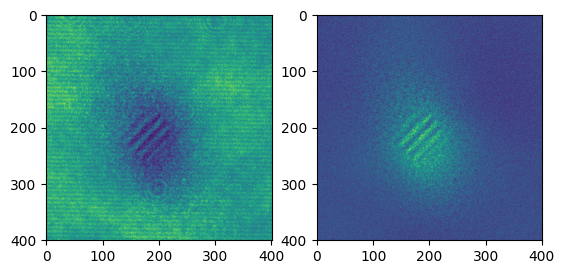

false

In [52]:
i, j = 5, 1

close("all")
fig, axs = subplots(1, 2)
axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :])
axs[2].imshow(ODs_dataset[i, j, :, :])
pygui(false)

# Save the ODs and negative ODs

In [48]:
if !isdir("Images")
    mkdir("Images")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
end

"Images/2026_02_11_0001/Negative_ODs"

In [49]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(unique(Amplitude_laser)[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(unique(Amplitude_laser)[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="plasma") #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(unique(Amplitude_laser)[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]
5.3%┣██▎                                        ┫ 1/19 [00:04<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:07<02:05, 7s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:11<01:26, 5s/it]
21.1%┣██████████                                     ┫ 4/19 [00:14<01:11, 5s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:18<01:02, 4s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:21<00:55, 4s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:25<00:50, 4s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:29<00:46, 4s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:33<00:42, 4s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:37<00:37, 4s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:42<00:33, 4s/it]
63.2%┣██████████████████████

In [50]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(unique(Amplitude_laser)[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(unique(Amplitude_laser)[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
        cb = colorbar(img)
        
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(unique(Amplitude_laser)[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]
5.3%┣██▎                                        ┫ 1/19 [00:04<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:08<02:20, 8s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:12<01:35, 6s/it]
21.1%┣██████████                                     ┫ 4/19 [00:15<01:17, 5s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:19<01:08, 5s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:23<01:00, 5s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:27<00:54, 4s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:31<00:49, 4s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:34<00:43, 4s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:38<00:38, 4s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:42<00:33, 4s/it]
63.2%┣██████████████████████

# Brouillons

In [51]:
# files_path = readdir(pathdir)[end]
# # imshow(load_crop_imgs([files_path], pathdir, x_crop, y_crop))
# a = load_crop_imgs([files_path], pathdir, x_crop, y_crop)[1][1]-load_crop_imgs([files_path], pathdir, x_crop, y_crop)[2][1]
# imshow(a, cmap="plasma") # vmin=0

<!-- Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop)))

for i in 1:length(Imgs_atoms_crop)
        idx_line = findfirst(==(Intensities[i]), unique(Intensities))
        println(idx_line)
        idx_row = floor(Int64, ((i-1)/(length(Sat))+1))
        println(idx_row)
        Imgs_atoms_crop_ds[idx_line, idx_row, :, :] .= Imgs_atoms_crop[i]
        Imgs_bkg_crop_ds[idx_line, idx_row, :, :] .= Imgs_bkg_crop[i]
        Imgs_dark_crop_ds[idx_line, idx_row, :, :] .= Imgs_dark_crop[i]
end -->